## Setting Up Enviroment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

Matplotlib is building the font cache; this may take a moment.


## Loading The Data 

In [6]:
train = pd.read_csv('../data/raw/Train.csv')
test = pd.read_csv('../data/raw/Test.csv')
var_defs = pd.read_csv('../data/raw/VariableDefinitions.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Variable definitions", var_defs)

Train shape: (18506, 21)
Test shape: (6169, 20)
Variable definitions               Column Name                                         Definition
0                      id                 Unique identifier for each tourist
1                 country                The country a tourist coming  from.
2               age_group                        The age group of a tourist.
3             travel_with  The relation of people a tourist travel with t...
4            total_female                            Total number of females
5              total_male                              Total number of males
6                 purpose                  The purpose of visiting  Tanzania
7           main_activity           The main activity of tourism in Tanzania
8            infor_source  The source of information about tourism in Tan...
9         tour_arrangment                The arrangment of visiting Tanzania
10  package_transport_int  If the tour package include international tran...
11   pa

## Structural Overview

In [9]:
# Structural Overview for the Training Data
train.info()
train.head()
train.dtypes.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 18506 entries, 0 to 18505
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Tour_ID                18506 non-null  str    
 1   country                18506 non-null  str    
 2   age_group              18506 non-null  str    
 3   travel_with            17431 non-null  str    
 4   total_female           18504 non-null  float64
 5   total_male             18500 non-null  float64
 6   purpose                18506 non-null  str    
 7   main_activity          18506 non-null  str    
 8   info_source            18506 non-null  str    
 9   tour_arrangement       18506 non-null  str    
 10  package_transport_int  18506 non-null  str    
 11  package_accomodation   18506 non-null  str    
 12  package_food           18506 non-null  str    
 13  package_transport_tz   18506 non-null  str    
 14  package_sightseeing    18506 non-null  str    
 15  package_guide

str        17
float64     2
int64       2
Name: count, dtype: int64

In [10]:
# Structural Overview for the Testing Data
test.info()
test.head()
test.dtypes.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 6169 entries, 0 to 6168
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Tour_ID                6169 non-null   str    
 1   country                6169 non-null   str    
 2   age_group              6169 non-null   str    
 3   travel_with            5808 non-null   str    
 4   total_female           6167 non-null   float64
 5   total_male             6168 non-null   float64
 6   purpose                6169 non-null   str    
 7   main_activity          6169 non-null   str    
 8   info_source            6169 non-null   str    
 9   tour_arrangement       6169 non-null   str    
 10  package_transport_int  6169 non-null   str    
 11  package_accomodation   6169 non-null   str    
 12  package_food           6169 non-null   str    
 13  package_transport_tz   6169 non-null   str    
 14  package_sightseeing    6169 non-null   str    
 15  package_guided_

str        16
float64     2
int64       2
Name: count, dtype: int64

## Checking for missing values

In [11]:
# Checking for missing training data
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_train_pct = (missing_train / len(train) * 100).round(2)
missing_summary = pd.concat([missing_train, missing_train_pct], axis=1, keys=['count', 'pct'])
missing_summary[missing_summary['count'] > 0]

,count,pct
travel_with,1075,5.81
total_male,6,0.03
total_female,2,0.01


In [12]:
# Checking for missing testing data
missing_test = test.isnull().sum().sort_values(ascending=False)
missing_test_pct = (missing_test / len(test) * 100).round(2)
missing_summary = pd.concat([missing_test, missing_test_pct], axis=1, keys=['count', 'pct'])
missing_summary[missing_summary['count'] > 0]

,count,pct
travel_with,361,5.85
total_female,2,0.03
total_male,1,0.02


<Axes: >

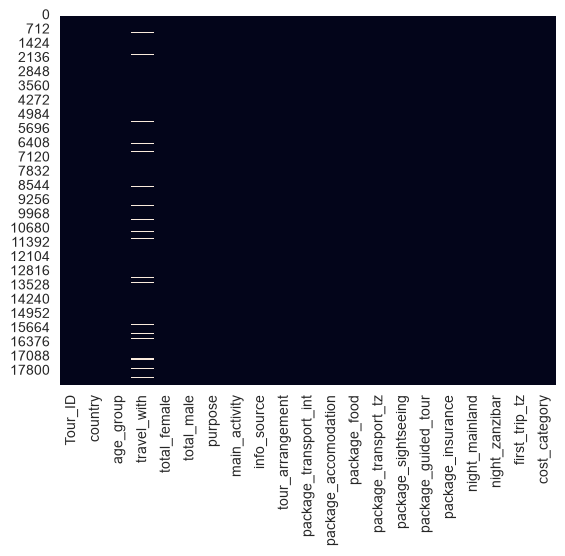

In [20]:
# Heatmap for missing training data
sns.heatmap(train.isnull(), cbar=False)

<Axes: >

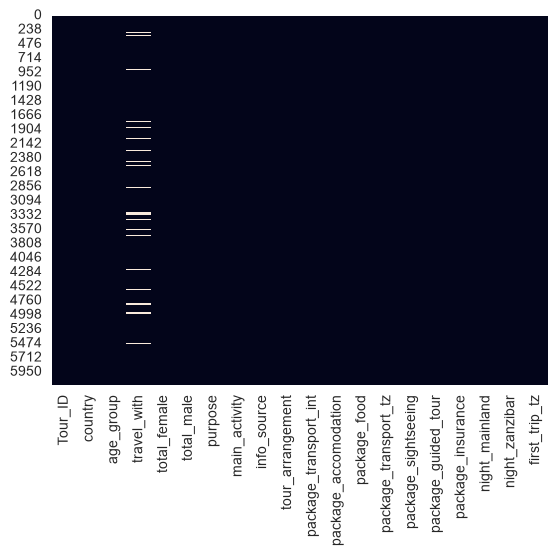

In [17]:
# Heatmap for missing testing data
sns.heatmap(test.isnull(), cbar=False)

## Checking for Duplicates

In [26]:
# Checking for duplicates in the training data
train.duplicated().sum()

np.int64(0)

In [22]:
# Checking for duplicates in the testing ata
test.duplicated().sum()

np.int64(0)